# Notebook 5 - Bivariate Analysis



## Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

possible_names = ["healthcare_dataset.csv", "Healthcare_dataset.csv", "Healthcare Dataset.csv", "healthcare-dataset.csv"]
data_path = None

for name in possible_names:
    if os.path.exists(name):
        data_path = name
        break

if data_path is None:
    print("Could not find the dataset automatically.")
    print("Current folder:", os.getcwd())
    print("Files in this folder:", os.listdir())
else:
    print("Found dataset at:", data_path)

df = pd.read_csv(data_path)
df.head()

Found dataset at: healthcare_dataset.csv


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


# Numerical vs Numerical

A scatter plot is the standard way to check whether two numerical variables move together, and the correlation coefficient gives a single number summarizing the strength and direction of that relationship (from -1, a perfect inverse relationship, to +1, a perfect direct relationship).

## Age vs Billing Amount

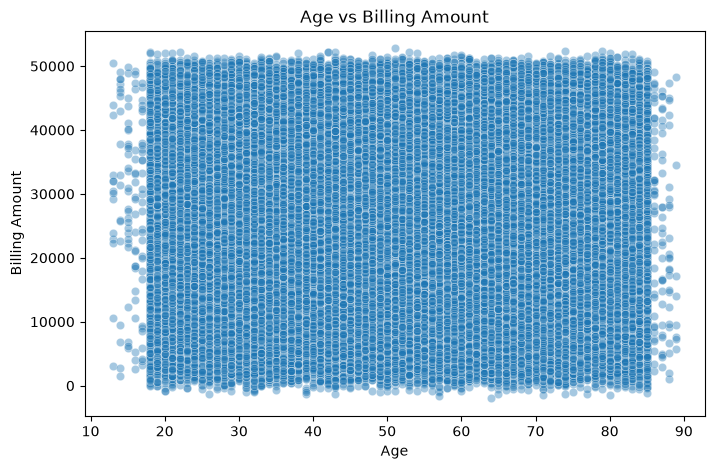

In [2]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Age", y="Billing Amount", data=df, alpha=0.4)
plt.title("Age vs Billing Amount")
plt.show()

In [3]:
df["Age"].corr(df["Billing Amount"])

np.float64(-0.003831942118617667)

The scatter plot shows points scattered broadly across the whole age range with no visible upward or downward trend, and the correlation coefficient is close to zero. In other words, a patient's age has essentially no relationship with how much they get billed in this dataset — younger and older patients are billed across the same wide range.

# Numerical vs Categorical

When comparing a numerical variable across categories, box plots and violin plots both show how the distribution differs by group. A box plot highlights the median and quartiles for each category, while a violin plot adds the full shape of the distribution, which can reveal patterns a box plot would flatten out.

## Billing Amount by Admission Type

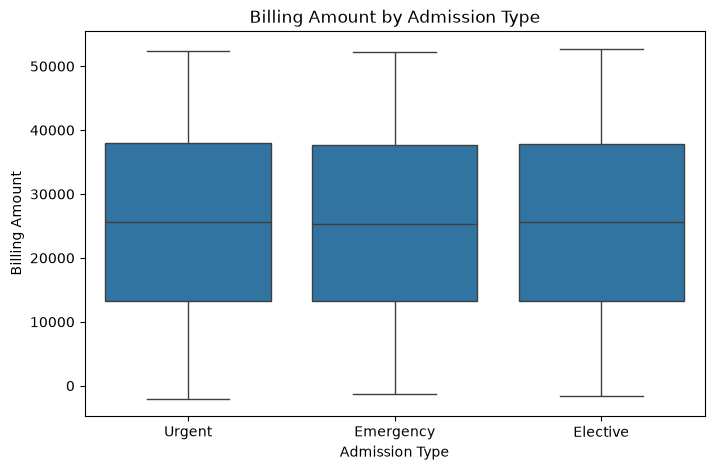

In [4]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Admission Type", y="Billing Amount", data=df)
plt.title("Billing Amount by Admission Type")
plt.show()

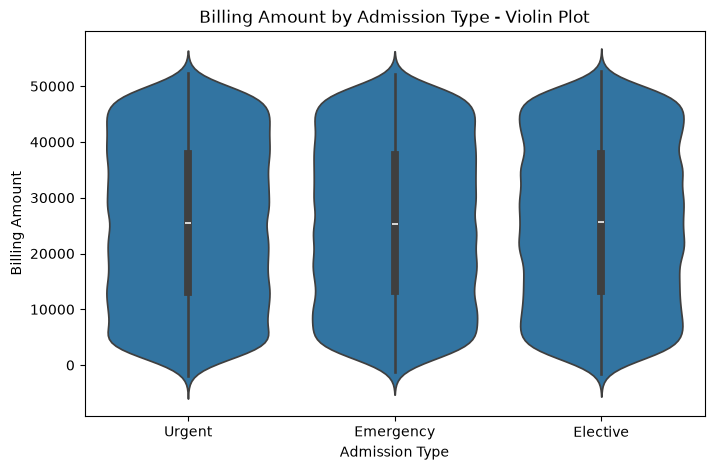

In [5]:
plt.figure(figsize=(8,5))
sns.violinplot(x="Admission Type", y="Billing Amount", data=df)
plt.title("Billing Amount by Admission Type - Violin Plot")
plt.show()

In [6]:
df.groupby("Admission Type")["Billing Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Admission Type,,,,,,,,
Elective,18655.0,25602.226311,14228.275326,-1660.009373,13285.377570,25656.932458,37840.978106,52764.276736
Emergency,18269.0,25497.397157,14163.005577,-1316.618581,13265.691840,25379.570923,37689.484709,52271.663747
Urgent,18576.0,25517.364497,14242.632174,-2008.492140,13192.684848,25550.368225,37910.313100,52373.032374


The median billing amount is very close across Emergency, Elective, and Urgent admissions, and the violin plot shows a similarly wide spread for each type. Admission type alone doesn't appear to drive cost in this dataset — all three types cover a comparably broad billing range.

## Age by Test Results

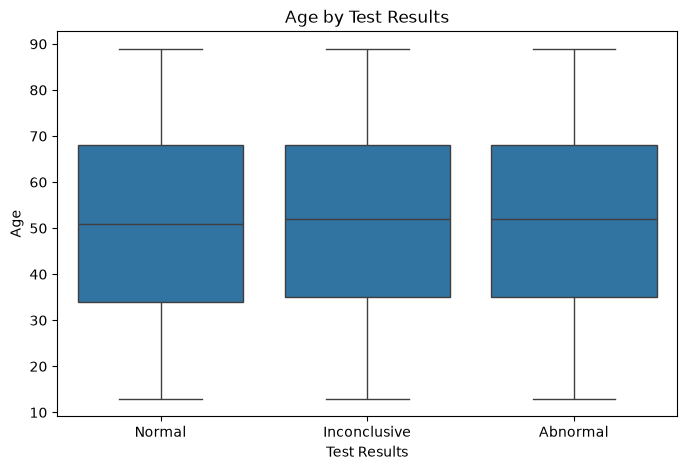

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Test Results", y="Age", data=df)
plt.title("Age by Test Results")
plt.show()

In [8]:
df.groupby("Test Results")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Test Results,,,,,,,,
Abnormal,18627.0,51.625919,19.560592,13.0,35.0,52.0,68.0,89.0
Inconclusive,18356.0,51.677871,19.537326,13.0,35.0,52.0,68.0,89.0
Normal,18517.0,51.315278,19.707791,13.0,34.0,51.0,68.0,89.0


Median age is similar across the Normal, Abnormal, and Inconclusive groups, suggesting age on its own is not a strong differentiator of test outcome in this dataset.

## Billing Amount by Gender

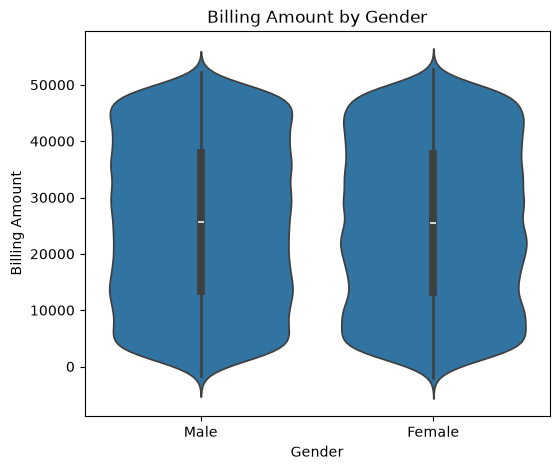

In [9]:
plt.figure(figsize=(6,5))
sns.violinplot(x="Gender", y="Billing Amount", data=df)
plt.title("Billing Amount by Gender")
plt.show()

In [10]:
df.groupby("Gender")["Billing Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,27726.0,25470.652958,14204.002670,-2008.492140,13146.274441,25425.248137,37740.838179,52764.276736
Male,27774.0,25607.860571,14218.814406,-1660.009373,13326.114693,25681.043366,37891.761520,52271.663747


Male and Female patients show very similar billing distributions, both in median and overall spread — gender does not appear to be associated with billing amount here.

# Categorical vs Categorical

For two categorical variables, a cross-tabulation counts how often each combination of categories occurs, and a grouped bar chart visualizes those counts side by side, making it easy to spot whether one category is disproportionately associated with another.

## Gender vs Test Results

In [11]:
pd.crosstab(df["Gender"], df["Test Results"])

Test Results,Abnormal,Inconclusive,Normal
Gender,,,
Female,9338,9216,9172
Male,9289,9140,9345


In [12]:
pd.crosstab(df["Gender"], df["Test Results"], normalize="index") * 100

Test Results,Abnormal,Inconclusive,Normal
Gender,,,
Female,33.679579,33.239559,33.080863
Male,33.444949,32.908476,33.646576


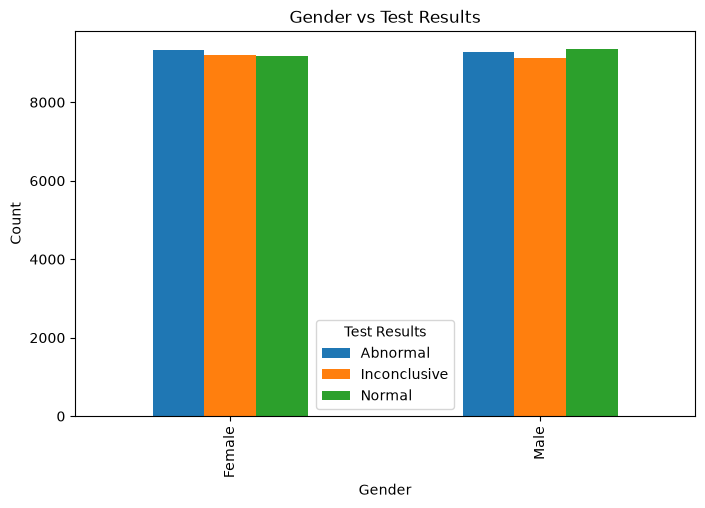

In [13]:
pd.crosstab(df["Gender"], df["Test Results"]).plot(kind="bar", figsize=(8,5))
plt.title("Gender vs Test Results")
plt.ylabel("Count")
plt.show()

The percentage breakdown is nearly identical between Male and Female patients across all three test outcomes. There's no indication that gender is associated with the test result in this dataset.

## Admission Type vs Test Results

In [14]:
pd.crosstab(df["Admission Type"], df["Test Results"])

Test Results,Abnormal,Inconclusive,Normal
Admission Type,,,
Elective,6296,6118,6241
Emergency,6091,6072,6106
Urgent,6240,6166,6170


In [15]:
pd.crosstab(df["Admission Type"], df["Test Results"], normalize="index") * 100

Test Results,Abnormal,Inconclusive,Normal
Admission Type,,,
Elective,33.749665,32.795497,33.454838
Emergency,33.340632,33.236630,33.422738
Urgent,33.591731,33.193368,33.214901


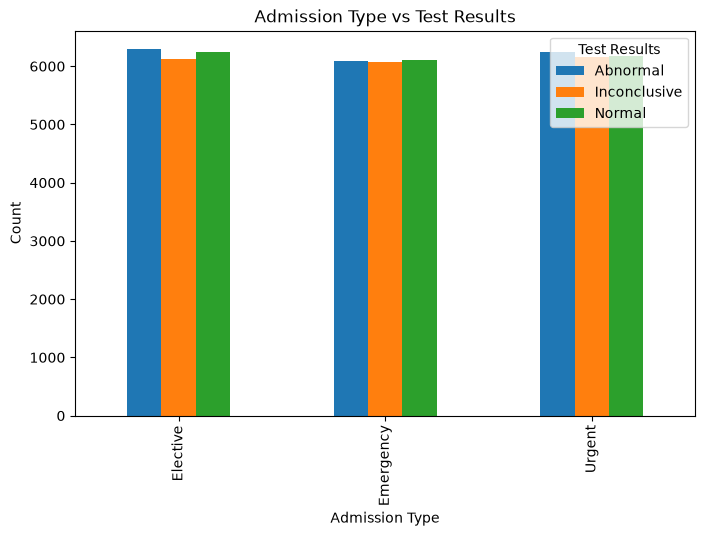

In [16]:
pd.crosstab(df["Admission Type"], df["Test Results"]).plot(kind="bar", figsize=(8,5))
plt.title("Admission Type vs Test Results")
plt.ylabel("Count")
plt.show()

As with gender, the proportion of Normal, Abnormal, and Inconclusive results is fairly consistent across Emergency, Elective, and Urgent admissions — admission type doesn't appear to strongly predict the test outcome on its own.

## Blood Type vs Medical Condition

In [17]:
pd.crosstab(df["Blood Type"], df["Medical Condition"])

Medical Condition,Arthritis,Asthma,Cancer,Diabetes,Hypertension,Obesity
Blood Type,,,,,,
A+,1116,1135,1185,1213,1128,1179
A-,1153,1173,1134,1167,1199,1143
AB+,1130,1189,1112,1173,1215,1128
AB-,1192,1134,1198,1139,1125,1157
B+,1201,1108,1196,1188,1103,1149
B-,1169,1119,1144,1151,1173,1188
O+,1198,1173,1108,1151,1157,1130
O-,1149,1154,1150,1122,1145,1157


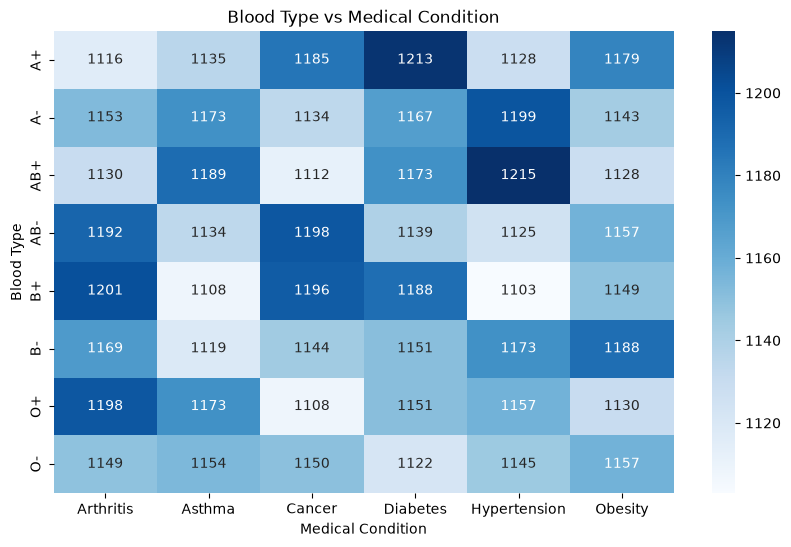

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(pd.crosstab(df["Blood Type"], df["Medical Condition"]), annot=True, fmt="d", cmap="Blues")
plt.title("Blood Type vs Medical Condition")
plt.show()

The counts are fairly evenly spread across the grid, with no blood type standing out as unusually linked to a particular medical condition. This lines up with the medical understanding that blood type isn't a risk factor for the conditions recorded here.